# Watershed Map for the North Branch of the Chicago River

Watersheds, waterbodies and flowlines for the North branch of the Chicago River including the North Shore Channel.

This notebook queries [The National Map](https://hydro.nationalmap.gov) API for watersheds, waterbodies, and flow lines.

- Watershed Boundary Dataset (WBD): The most current national Hydrologic Unit (HU) data set. 
   - Hydrological Unit Code (HUC): a unique code for each drainage. 
     - HUC-8: Eight-digit code. (for overviews and broad assessments)
     - HUC-12: Twelve-digit code. (for detailed watershed analysis)
- National Hydrography Dataset (NHD) contains information about the nation's surface waters. This includes
    - Flowlines
    - Waterbody polygons

This notebook plots HUC-12 watersheds for the North Branch of the Chicago River and the North Shore Channel.
It includes waterbodies, flowlines, gauge locations, the locations of water reclamation plants, and other points of interest. 

River Segments are distinguished by a combination of waterbody name and watershed.

| Key | Waterbody | Watershed | Notes | 
| --- | --- | --- | --- |
| NBCR_Lower | NBCR | Lower Branch Chicago River | below River Park |
| NSC | North Shore Channel | North Shore Channel | above River Park |
| NBCR_Middle | NBCR |  Middle NBCR  | above River Park, below West Fork |
| WF | West Fork NBCR | WF NBCR |
| MF_Middle | Middle Fork NBCR | Middle NBCR |above West fork below Skokie River |
| MF_Upper | Middle Fork NBCR | Upper NBCR | above SR-MFNBCR confuence |
| SR | Skokie River  | Skokie River | above SR-MFNBCR confluence |

This notebook uses the following coordinates for confluences: 

| Confluence       | lat | lon | 
| --- | --- | --- |
| NBCR NS-Channel  | 41.97387 | - 87.70436 |
| WF-NBCR MF-NBCR | 42.05241 | -87.780416 | 
| MF-NBCR Skokie River | 42.08765 | -87.77181 |

Breaking river segments with confluence coordinates is fragile and should be replaced when 3DHP comes online.

## License
Copyright (C) 2025 Greg Anderson

This notebook and the accompanying `NationalMapClient.py` are free software: 
you can redistribute them and/or modify them under the terms of the 
[GNU General Public License v3](LICENSE) as published by the Free Software Foundation.

Data from USGS National Map services is in the public domain.


In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import importlib

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib_scalebar.scalebar import ScaleBar
import contextily as cx

import national_map_client
from national_map_client import WBDClient, NHDPlusFlowlineClient, NHDWaterbodyClient

## Data Sources

| Flowtype       | ftype(ID) |  fcodes | |
| --- | --- | --- | -- | 
| Pipeline       | 428 | 42800, 42816, 42801, ... | |
| ArtificialPath | 558 | 55800 |centerline through waterbodies or engineered channels |
| Connector      | 334 | 33400 | |
| StreamRiver    | 460 | 46000, 46003, 46006,... | |
| CanalDitch     | 336 | 33600, 33601, 33603 | |
| Coastline      | 566 | 56600 | |


In [ ]:
# Initialize specialized clients

wbd_client = WBDClient()                # USGS-USDA-NRCS Watershed Boundary Dateset (WBD) 12-digit HU (Subwatershed)
nhd_flow_client = NHDPlusFlowlineClient()   # USGS National Hydrography Dataset (NHD): Flowline (Large Scale)
waterbody_client = NHDWaterbodyClient() # USGS NHD Waterbody (Large Scale)

## Watersheds

In [ ]:
# Map extent
bbox = "-87.98,41.80,-87.55,42.35"

nearby_watersheds = wbd_client.query(
    bbox=bbox, 
    where_clause="states LIKE '%IL%'", 
    out_fields="name,huc12,states,tohuc,areasqkm"
)

print(nearby_watersheds[["name", "huc12", "tohuc", "areasqkm"]].drop_duplicates().sort_values("huc12").to_string(index=False))
print("CRS:", nearby_watersheds.crs)

                                                      name        huc12        tohuc  areasqkm
                      Waukegan River-Frontal Lake Michigan 040400020501 041900000200    130.89
                     Diversey Harbor-Frontal Lake Michigan 040400020502 041900000200     55.82
                   Oakwoods Cemetery-Frontal Lake Michigan 040400020503 041900000200     38.05
                                             Lake Michigan 041900000200 042400000000  58171.01
                                              Skokie River 071200030101 071200030105     78.25
                          Upper North Branch Chicago River 071200030102 071200030105     62.00
                      West Fork North Branch Chicago River 071200030103 071200030105     74.20
                                       North Shore Channel 071200030104 071200030106     59.44
                         Middle North Branch Chicago River 071200030105 071200030106     73.53
                          Lower North Branch Chica

In [ ]:
# keep 6 watersheds of interest and assign them colors.
keep_huc12 = [
    "071200030101",  # Skokie River
    "071200030102",  # Upper North Branch Chicago River
    "071200030103",  # West Fork North Branch Chicago River
    "071200030104",  # North Shore Channel
    "071200030105",  # Middle North Branch Chicago River
    "071200030106",  # Lower North Branch Chicago River
]

selected_watersheds = nearby_watersheds[nearby_watersheds["huc12"].isin(keep_huc12)].copy()

# All watersheds except Lower North Branch
upper_watersheds = selected_watersheds[
    selected_watersheds["name"] != "Lower North Branch Chicago River"
]
print(selected_watersheds[["name", "huc12", "tohuc", "areasqkm"]].sort_values("huc12").to_string(index=False))

                                name        huc12        tohuc  areasqkm
                        Skokie River 071200030101 071200030105     78.25
    Upper North Branch Chicago River 071200030102 071200030105     62.00
West Fork North Branch Chicago River 071200030103 071200030105     74.20
                 North Shore Channel 071200030104 071200030106     59.44
   Middle North Branch Chicago River 071200030105 071200030106     73.53
    Lower North Branch Chicago River 071200030106 071200030107    109.27


## Flowlines

In [ ]:
nearby_flowlines = nhd_flow_client.query(mask=selected_watersheds,normalize_columns=True)

# Verification 
name_col = "gnis_name"
print(nearby_flowlines[[name_col, "ftype", "fcode", "reachcode"]].drop_duplicates().sort_values([name_col, "ftype", "fcode"]).to_string(index=False))
print("CRS:", nearby_flowlines.crs)
print("Total flowlines:", len(nearby_flowlines))

                           gnis_name  ftype  fcode      reachcode
                       Addison Creek    460  46003 07120004000229
                       Addison Creek    460  46006 07120004000229
                       Addison Creek    558  55800 07120004000229
                   Bensenville Ditch    334  33400 07120004002765
                   Bensenville Ditch    460  46003 07120004002765
                   Bensenville Ditch    460  46006 07120004002765
                   Bensenville Ditch    558  55800 07120004002765
                       Chicago River    558  55800 07120003000905
                       Crystal Creek    334  33400 07120004000732
                       Crystal Creek    460  46003 07120004000732
                       Crystal Creek    558  55800 07120004000732
                   Des Plaines River    558  55800 07120004000063
                   Des Plaines River    558  55800 07120004000064
                   Des Plaines River    558  55800 07120004000065
          

In [ ]:

selected_flowlines = nearby_flowlines[
    nearby_flowlines[name_col].isin([
        "North Branch Chicago River",
        "South Branch Chicago River",
        "Chicago River",
        "West Fork North Branch Chicago River",
        "North Shore Channel",
        "Skokie River",
        "Skokie Ditch",
    ])
].copy()

# Verification
print(selected_flowlines[[name_col, "ftype", "fcode", "reachcode", "lengthkm"]].drop_duplicates().sort_values([name_col, "ftype", "fcode"]).to_string(index=False))
print("Selected flowlines:", len(selected_flowlines))


                           gnis_name  ftype  fcode      reachcode  lengthkm
                       Chicago River    558  55800 07120003000905  2.061000
          North Branch Chicago River    460  46003 07120003000872  0.296000
          North Branch Chicago River    460  46003 07120003000611  0.134000
          North Branch Chicago River    460  46003 07120003000611  0.289000
          North Branch Chicago River    460  46003 07120003000611  0.146000
          North Branch Chicago River    460  46003 07120003000872  0.162000
          North Branch Chicago River    460  46003 07120003000872  0.099000
          North Branch Chicago River    460  46006 07120003000005  0.657000
          North Branch Chicago River    460  46006 07120003000005  0.969000
          North Branch Chicago River    460  46006 07120003000004  0.506000
          North Branch Chicago River    460  46006 07120003000005  0.961000
          North Branch Chicago River    460  46006 07120003000005  0.017000
          No

In [ ]:
from shapely.geometry import box

# Confluence latitudes
LAT_RIVER_PARK = 41.97387  # NBCR / North Shore Channel confluence
LAT_WF_MF      = 42.05241  # West Fork / Middle Fork confluence  
LAT_MF_SKOKIE  = 42.08765  # Middle Fork / Skokie River confluence

# Rename remaining flowlines to short keys
selected_flowlines = selected_flowlines.copy()
selected_flowlines[name_col] = selected_flowlines[name_col].replace({
    "West Fork North Branch Chicago River": "WF",
    "North Shore Channel": "NSC",
    "Skokie River": "SR",
})

# Split "North Branch Chicago River" into three segments by latitude
nbcr = selected_flowlines[selected_flowlines[name_col] == "North Branch Chicago River"].copy()

# Segment 3: NBCR_Middle — main stem above River Park to West Fork
seg_NBCR_Middle = gpd.clip(nbcr, gpd.GeoDataFrame(
    geometry=[box(-88, 41.96, -87, LAT_WF_MF)], crs="EPSG:4326"))
seg_NBCR_Middle = seg_NBCR_Middle.copy()
seg_NBCR_Middle[name_col] = "NBCR_Middle"

# Segment 5: MF_Middle — Middle Fork below Skokie confluence
seg_MF_Middle = gpd.clip(nbcr, gpd.GeoDataFrame(
    geometry=[box(-88, LAT_WF_MF, -87, LAT_MF_SKOKIE)], crs="EPSG:4326"))
seg_MF_Middle = seg_MF_Middle.copy()
seg_MF_Middle[name_col] = "MF_Middle"

# Segment 6: MF_Upper — Middle Fork above Skokie confluence
seg_MF_Upper = gpd.clip(nbcr, gpd.GeoDataFrame(
    geometry=[box(-88, LAT_MF_SKOKIE, -87, 43)], crs="EPSG:4326"))
seg_MF_Upper = seg_MF_Upper.copy()
seg_MF_Upper[name_col] = "MF_Upper"

# Unnamed lower segments
lower_ws = selected_watersheds[selected_watersheds["name"] == "Lower North Branch Chicago River"]
unnamed_in_lower = gpd.clip(
    nearby_flowlines[nearby_flowlines[name_col].isna()],
    lower_ws
).copy()
unnamed_in_lower[name_col] = "NBCR_Lower"

# Rebuild selected_flowlines with all renamed segments
selected_flowlines = gpd.GeoDataFrame(
    pd.concat([
        selected_flowlines[selected_flowlines[name_col] != "North Branch Chicago River"],
        seg_NBCR_Middle,
        seg_MF_Middle,
        seg_MF_Upper,
        unnamed_in_lower,
    ], ignore_index=True),
    crs=selected_flowlines.crs
)

unnamed_segments = gpd.clip(
    nearby_flowlines[
        nearby_flowlines[name_col].isna() &
        ~nearby_flowlines["ftype"].isin([428, 566])
    ],
    upper_watersheds
)

## Waterbodies

In [ ]:
# Fetch waterbody data using the client
#waterbodies = waterbody_client.query(bbox=bbox,normalize_columns=True)
waterbodies = waterbody_client.query(mask=selected_watersheds,normalize_columns=True)
waterbodies = gpd.clip(waterbodies, selected_watersheds)

# Diagnostic steps
print("Columns:", waterbodies.columns.tolist())
print(waterbodies.geom_type.value_counts())
print(
    waterbodies[["gnis_name", "ftype", "fcode"]]
    .drop_duplicates()
    .sort_values(["gnis_name", "ftype", "fcode"])
    .to_string(index=False)
)

Columns: ['objectid', 'permanent_identifier', 'fdate', 'resolution', 'gnis_id', 'gnis_name', 'areasqkm', 'elevation', 'reachcode', 'ftype', 'fcode', 'visibilityfilter', 'shape_length', 'shape_area', 'globalid', 'geometry']
Polygon    821
Name: count, dtype: int64
             gnis_name  ftype  fcode
          Lake Eleanor    390  39004
         Lake Michigan    390  39010
            Lambs Lake    390  39004
            Lucky Lake    390  39004
Shady Lane Resort Lake    390  39004
        Skokie Lagoons    390  39004
             West Lake    390  39004
                   NaN    390  39001
                   NaN    390  39004
                   NaN    390  39009
                   NaN    390  39011
                   NaN    436  43600
                   NaN    436  43613
                   NaN    436  43624
                   NaN    466  46600


## Gauges, outfalls and other points of interest

Edit coordinates and label offsets as needed. `dx_m` and `dy_m` are label offsets in map meters after reprojection to EPSG:3857.
The USGS Gauge at Highland Park (05535070) is attached to the upstream (North) face of the Clavey Road Bridge. The outfall (Discharge 010) is pumped almost 1.5 miles south at Dundee Road, just above Skokie Lagoons.

In [ ]:
# Mean cfs from 2025, (2010 last available cfs for Grand Ave guage)
gauges_df = pd.DataFrame([
    {"name": "Lake Forest gauge",  "lon": -87.84523, "lat": 42.2325,  "station": "05535000", "mean_cfs": 9.6},
    {"name": "Highland Park gauge","lon": -87.79805, "lat": 42.15972, "station": "05535070", "mean_cfs": 19.2},
    {"name": "Deerfield gauge",    "lon": -87.8186,  "lat": 42.1528,  "station": "05534500", "mean_cfs": 8.6},
    {"name": "Northbrook gauge",   "lon": -87.83472, "lat": 42.1383,  "station": "05535500", "mean_cfs": 10.7},
    {"name": "Niles gauge",        "lon": -87.7968,  "lat": 42.0094,  "station": "05536000", "mean_cfs": 70.6},
    {"name": "Pulaski gauge",      "lon": -87.7283,  "lat": 41.9747,  "station": "05536085", "mean_cfs": 79.8},  
    {"name": "Grand Ave gauge",      "lon": -87.6419,  "lat": 41.8917,  "station": "05536118", "mean_cfs": 500},
])

locations_df = pd.DataFrame([
    {"name": "River Park",         "lon": -87.7000, "lat": 41.9700},
    {"name": "O'Brien WRP",        "lon": -87.7117, "lat": 42.0200},
    {"name": "Discharge 010",      "lon": -87.7868, "lat": 42.1375},
    {"name": "Clavey Rd WRP",      "lon": -87.7975, "lat": 42.1597},
    {"name": "Deerfield WRP",      "lon": -87.8563, "lat": 42.1602},
    {"name": "Wilmette PS",        "lon": -87.6851, "lat": 42.0755},
    {"name": "NEIU",               "lon": -87.7185, "lat": 41.97909},
])

gauges_gdf = gpd.GeoDataFrame(
    gauges_df,
    geometry=gpd.points_from_xy(gauges_df["lon"], gauges_df["lat"]),
    crs="EPSG:4326",
)

locations_gdf = gpd.GeoDataFrame(
    locations_df,
    geometry=gpd.points_from_xy(locations_df["lon"], locations_df["lat"]),
    crs="EPSG:4326",
)


## Visualization

In [ ]:
# Map Style Configuration

# Individual watershed styling / display labels
# Watershed labels (offsets are in Web Mercator meters)
watershed_style = {
    "Skokie River": {
        "fill": "#d6e6f5",
        "label": "Skokie River",
        "dx_m": -200,  "dy_m": 7100,
    },
    "Upper North Branch Chicago River": {
        "fill": "#bdd7ee",
        "label": "Upper NBCR",
        "dx_m": 500,   "dy_m": -1800,
    },
    "West Fork North Branch Chicago River": {
        "fill": "#9ecae1",
        "label": "West Fork NBCR",
        "dx_m": 0,     "dy_m": -3700,  
    },
    "Middle North Branch Chicago River": {
        "fill": "#7fb9dd",
        "label": "Middle NBCR",
        "dx_m": -1900, "dy_m": 1200,
    },
    "North Shore Channel": {
        "fill": "#a1d99b",
        "label": "North Shore Channel",
        "dx_m": 1800,  "dy_m": -3500,
    },
    "Lower North Branch Chicago River": {
        "fill": "#fdd0a2",
        "label": "Lower North Branch",
        "dx_m": 0,     "dy_m": 0,
    },
}

selected_watersheds["fill_color"] = selected_watersheds["name"].map(lambda n: watershed_style[n]["fill"])
selected_watersheds["display_label"] = selected_watersheds["name"].map(lambda n: watershed_style[n]["label"])

gauge_style_all = {"fontsize": 8, "fontstyle": "italic", "color": "#444444"}

gauges_style = {
    "Lake Forest gauge":   {"dx_m": -1000, "dy_m": 0},
    "Highland Park gauge": {"dx_m":  1000, "dy_m": 600},
    "Deerfield gauge":     {"dx_m": -1000, "dy_m": 100},
    "Northbrook gauge":    {"dx_m": -1000, "dy_m": 0},
    "Niles gauge":         {"dx_m": -1000, "dy_m": -600},
    "Pulaski gauge":       {"dx_m": -1400, "dy_m": -600},
    "Grand Ave gauge":       {"dx_m": -1400, "dy_m": -600},
}

locations_style = {
    "River Park":      {"fontsize": 11, "fontweight": "bold",   "fontstyle": "normal", "color": "black", 
                        "marker_size": 50, "dx_m": 600,  "dy_m": 20,   "marker": "*"},
    "O'Brien WRP":     {"fontsize":  9, "fontweight": "normal", "fontstyle": "normal", "color": "black",
                        "marker_size": 40, "dx_m": -1000,"dy_m": 0,    "marker": "o"},
    "Discharge 010":   {"fontsize":  6, "fontweight": "normal", "fontstyle": "normal", "color": "black",
                        "marker_size": 20, "dx_m":  1000,"dy_m": -600,    "marker": "o"},
    "Clavey Rd WRP":   {"fontsize":  8, "fontweight": "normal", "fontstyle": "normal", "color": "black",
                        "marker_size": 30, "dx_m":  1000,"dy_m": -600,    "marker": "o"},
    "Deerfield WRP":   {"fontsize":  8, "fontweight": "normal", "fontstyle": "normal", "color": "black",
                        "marker_size": 30, "dx_m":-1000, "dy_m": 500,  "marker": "o"},
    "Wilmette PS":     {"fontsize":  8, "fontweight": "normal", "fontstyle": "normal", "color": "#222222",
                        "marker_size": 40, "dx_m":   500, "dy_m": 1500, "marker": "o"},
    "NEIU":            {"fontsize":  8, "fontweight": "normal", "fontstyle": "normal", "color": "#222222",
                        "marker_size": 30, "dx_m": -100,  "dy_m": 1500, "marker": "o"},
}

# Flowline styling

reach_flow_cfs = {
    "Middle Fork":        8.6,    # Deerfield gauge
    "West Fork":         10.7,    # Northbrook gauge
    "Skokie River":      19.2,    # Highland Park gauge
    "NBCR_Middle":       70.6,    # Niles gauge
    "North Shore Channel": 334.0,      # O'Brien
    "Lower Branch":     500.0,    # Grand Ave gauge
}

flowline_reach_groups = {
    "NBCR_Lower":   "Lower Branch",
    "NBCR_Middle":  "NBCR_Middle",
    "MF_Middle":    "Middle Fork",
    "MF_Upper":     "Middle Fork",
    "WF":           "West Fork",
    "SR":           "Skokie River",
    "Skokie Ditch": "Skokie River",
    "Chicago River":"Lower Branch",
    "NSC":          "North Shore Channel",
}

def sqrt_scaled_linewidth(q, q_min, q_max, lw_min=1.1, lw_max=4.2):
    q = float(q)
    s = (np.sqrt(q) - np.sqrt(q_min)) / (np.sqrt(q_max) - np.sqrt(q_min))
    return lw_min + s * (lw_max - lw_min)

q_min = min(reach_flow_cfs.values())
q_max = max(reach_flow_cfs.values())

LINEWIDTH_SCALE = 0.67

reach_linewidths = {
    reach: sqrt_scaled_linewidth(q, q_min, q_max) * LINEWIDTH_SCALE 
    for reach, q in reach_flow_cfs.items()
}

UPSTREAM_BRANCH_COLOR = "#4ea3d8"
LOWER_BRANCH_COLOR = "#e8891a"
CHANNEL_COLOR = "#1b9e77"

reach_colors = {
    "NBCR_Middle":   UPSTREAM_BRANCH_COLOR,
    "Middle Fork":   UPSTREAM_BRANCH_COLOR,
    "West Fork":     UPSTREAM_BRANCH_COLOR,
    "Skokie River":  UPSTREAM_BRANCH_COLOR,
    "North Shore Channel":   CHANNEL_COLOR,
    "Lower Branch":  LOWER_BRANCH_COLOR,
}

selected_flowlines["reach_group"] = selected_flowlines[name_col].map(flowline_reach_groups)
selected_flowlines["mean_cfs"] = selected_flowlines["reach_group"].map(reach_flow_cfs)
selected_flowlines["linewidth"] = selected_flowlines["reach_group"].map(reach_linewidths)
selected_flowlines["color"] = selected_flowlines["reach_group"].map(reach_colors)

# Fallbacks
selected_flowlines["color"] = selected_flowlines["color"].fillna("#888888")
selected_flowlines["linewidth"] = selected_flowlines["linewidth"].fillna(1.0)


In [ ]:
# Reproject everything to Web Mercator for contextily
# This must follow the style block

watersheds_3857 = selected_watersheds.to_crs(3857)
waterbodies_3857 = waterbodies.to_crs(3857)
flowlines_3857 = selected_flowlines.to_crs(3857)
gauges_3857 = gauges_gdf.to_crs(3857)
locations_3857 = locations_gdf.to_crs(3857)

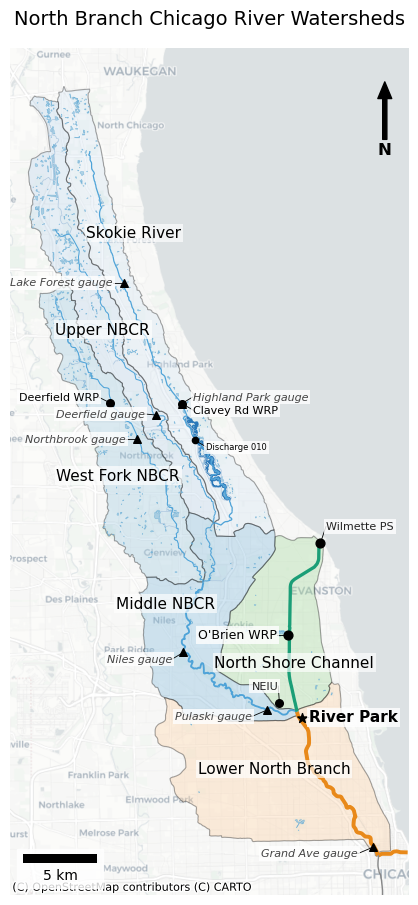

In [ ]:
fig, ax = plt.subplots(figsize=(11, 11))

watersheds_3857.plot(
    ax=ax,
    color=watersheds_3857["fill_color"],
    edgecolor="black",
    alpha=0.35,
    linewidth=0.8,
    zorder=2,
)

# Watershed labels (single label per watershed polygon)

for _, row in watersheds_3857.iterrows():
    pt = row.geometry.representative_point()
    style = watershed_style.get(row["name"], {"label": row["name"], "dx_m": 0, "dy_m": 0})
    ax.text(
        pt.x + style["dx_m"],
        pt.y + style["dy_m"],
        style["label"],
        fontsize=11,
        fontweight="normal",
        color="black",
        ha="center",
        va="center",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, pad=1.2),
        zorder=10,
    )

# Waterbodies
waterbodies_3857.plot(
    ax=ax,
    facecolor="#9ecae1",
    edgecolor="#6baed6",
    linewidth=0.4,
    alpha=0.75,
    zorder=3,
)

# Optional highlight for Skokie Lagoons

skokie_lagoons = waterbodies[waterbodies["gnis_name"] == "Skokie Lagoons"].copy()
if not skokie_lagoons.empty:
    skokie_lagoons.to_crs(3857).plot(
        ax=ax,
        facecolor="#6baed6",
        edgecolor="#2171b5",
        linewidth=0.8,
        alpha=0.9,
        zorder=4,
    )

# Flowlines

for reach_group, subset in flowlines_3857.groupby("reach_group", dropna=False):
    if subset.empty:
        continue

    subset.plot(
        ax=ax,
        color=subset["color"].iloc[0],
        linewidth=subset["linewidth"].iloc[0],
        zorder=5,
    )
        
# Secondary unnamed drainage features

if not unnamed_segments.to_crs(3857).empty:
    unnamed_segments.to_crs(3857).plot(
        ax=ax,
        color="#aec8e0",
        linewidth=0.5,
        zorder=4,
    )

# Points: Gauges and locations

# USGS Gauges recording discharge 

gauges_3857.plot(
    ax=ax,
    color="black",
    markersize=30,
    marker="^",
    zorder=20,
)

# Gauges — labels

for _, row in gauges_3857.iterrows():
    
    x, y = row.geometry.x, row.geometry.y
    style = gauges_style.get(row["name"], {"dx_m": 0, "dy_m": 0})
    label_x = x + style["dx_m"]
    label_y = y + style["dy_m"]
    ax.plot([x, label_x], [y, label_y], color="black", linewidth=0.6, zorder=19)
    ax.text(
        label_x, label_y,
        row["name"],
        ha="left" if style["dx_m"] >= 0 else "right",
        va="center",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5),
        zorder=21,
        **gauge_style_all,
    )

# Locations — markers
for name, style in locations_style.items():
    subset = locations_3857[locations_3857["name"] == name]
    if not subset.empty:
        subset.plot(
            ax=ax,
            color="black",
            markersize=style["marker_size"],
            marker=style["marker"],
            zorder=20,
        )

# Locations — labels
for _, row in locations_3857.iterrows():
    x, y = row.geometry.x, row.geometry.y
    style = locations_style.get(
        row["name"],
        {"fontsize": 9, "fontweight": "normal", "fontstyle": "normal", "color": "black", "dx_m": 0, "dy_m": 0}
    )
    label_x = x + style["dx_m"]
    label_y = y + style["dy_m"]
    ax.plot([x, label_x], [y, label_y], color="black", linewidth=0.6, zorder=19)
    ax.text(
        label_x, label_y,
        row["name"],
        fontsize=style["fontsize"],
        fontweight=style["fontweight"],
        fontstyle=style["fontstyle"],
        color=style["color"],
        ha="left" if style["dx_m"] >= 0 else "right",
        va="center",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5),
        zorder=21,
    )
    
    
# Map extent from selected watersheds with padding
xmin, ymin, xmax, ymax = watersheds_3857.total_bounds
pad_x = 0.05 * (xmax - xmin)
pad_y = 0.05 * (ymax - ymin)
ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, alpha=0.8)

# North arrow
ax.annotate(
    "N",
    xy=(0.94, 0.96),      # arrow tip in axes fraction
    xytext=(0.94, 0.88),  # text position
    xycoords="axes fraction",
    textcoords="axes fraction",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    arrowprops=dict(facecolor="black", width=3, headwidth=10),
    zorder=30,
)

# Scale bar

lat0 = selected_watersheds.geometry.union_all().centroid.y
ground_m_per_mercator_m = np.cos(np.deg2rad(lat0))

scalebar = ScaleBar(
    dx=ground_m_per_mercator_m,                
    units="m",
    location="lower left",
    box_alpha=0.8,
    pad=0.4,
    border_pad=0.5,
    sep=4,
)
ax.add_artist(scalebar)

ax.set_title("North Branch Chicago River Watersheds", fontsize=14)
ax.set_axis_off()

plt.show()


## Output

In [ ]:
output_dir = Path("./figures")
output_dir.mkdir(exist_ok=True)

output_pdf = output_dir / "north_branch_watersheds.pdf"
output_png = output_dir / "north_branch_watersheds.png"

fig.savefig(output_pdf, format="pdf", bbox_inches="tight")
fig.savefig(output_png, dpi=300, bbox_inches="tight")

print(output_pdf)
print(output_png)


figures/north_branch_watersheds.pdf
figures/north_branch_watersheds.png
